In [1]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
import numpy as np
import pandas as pd
from sklearn.cluster import HDBSCAN
from sklearn.metrics import silhouette_samples
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')
import os
os.getcwd()

'c:\\Users\\Bruno\\Desktop\\Personal-projects-1\\Proyectos de Astronomía\\Laboratorio 4'

In [2]:
df = pd.read_csv("dataset_porcionado_con_clusters.csv").dropna(subset='pmra') # full gaia sample for one cluster
df = df.dropna(subset=['ra', 'dec', 'pmra','pmdec','parallax','bp_rp','phot_g_mean_mag'])
df.info(), df.columns

<class 'pandas.core.frame.DataFrame'>
Index: 348597 entries, 0 to 372110
Data columns (total 28 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Unnamed: 0                 348597 non-null  int64  
 1   source_id                  348597 non-null  int64  
 2   ra                         348597 non-null  float64
 3   dec                        348597 non-null  float64
 4   parallax                   348597 non-null  float64
 5   pmra                       348597 non-null  float64
 6   pmdec                      348597 non-null  float64
 7   ruwe                       348597 non-null  float64
 8   phot_g_mean_mag            348597 non-null  float64
 9   bp_rp                      348597 non-null  float64
 10  radial_velocity            168208 non-null  float64
 11  ra_error                   348597 non-null  float64
 12  dec_error                  348597 non-null  float64
 13  pmra_error                 348597 

(None,
 Index(['Unnamed: 0', 'source_id', 'ra', 'dec', 'parallax', 'pmra', 'pmdec',
        'ruwe', 'phot_g_mean_mag', 'bp_rp', 'radial_velocity', 'ra_error',
        'dec_error', 'pmra_error', 'pmdec_error', 'parallax_error',
        'visibility_periods_used', 'phot_bp_mean_mag', 'phot_rp_mean_mag',
        'nu_eff_used_in_astrometry', 'pseudocolour', 'ecl_lat',
        'astrometric_params_solved', 'zp', 'fidelity_v2', 'parallax.1',
        'parallax_over_error', 'cell_id'],
       dtype='object'))

In [3]:
# features derivadas
df["dist_pc"] = 1000 / df["parallax"]
df["parallax_over_error"] = df["parallax_error"] / df["parallax"]

# filtro global (opcional pero recomendable)
df = df[df["parallax_over_error"] <= 0.1]

Bruno = len(df)
print("Total estrellas inicial:", len(df))
print("Índices únicos:", df.index.nunique())

Total estrellas inicial: 348597
Índices únicos: 348597


  0%|          | 0/66 [00:00<?, ?it/s]


Cell 1
N estrellas: 1461
N clusters encontrados: 2
[TAMAÑO] Cluster 0 eliminado | N=56 | Δd=17.47 pc
[TAMAÑO] Cluster 1 eliminado | N=45 | Δd=14.12 pc
Todos los clusters eliminados tras cortes

Cell 2
N estrellas: 3967
N clusters encontrados: 2
[TAMAÑO] Cluster 0 eliminado | N=1600 | Δd=44.61 pc


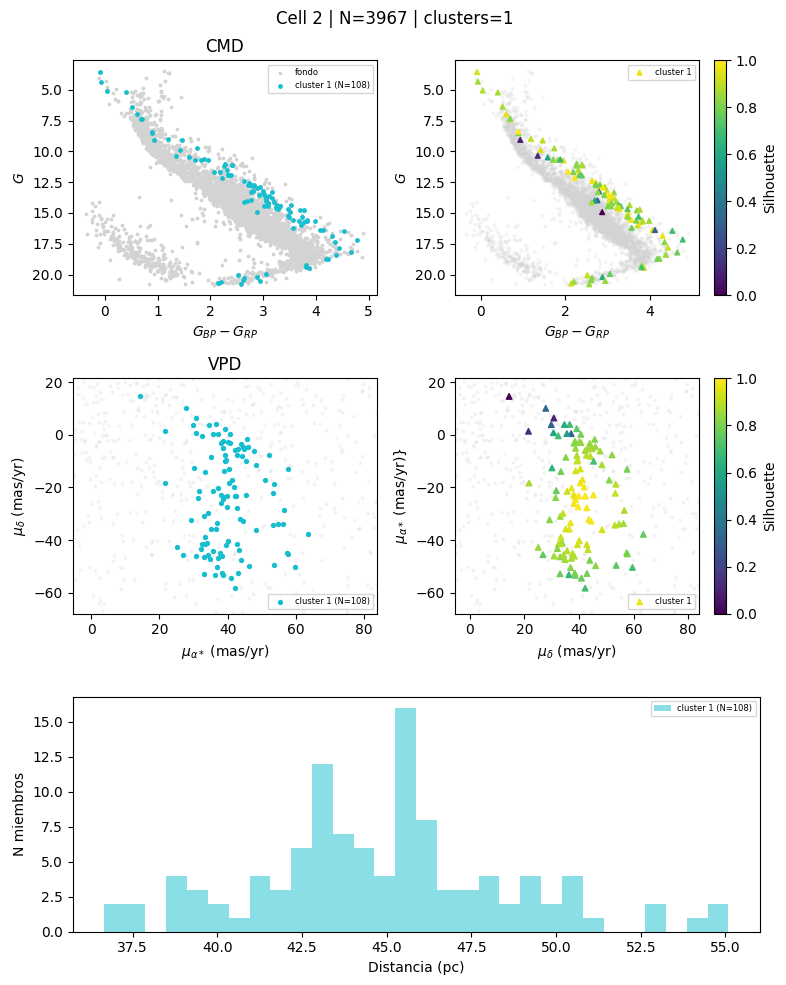

  3%|▎         | 2/66 [00:01<00:46,  1.39it/s]


Cell 3
N estrellas: 5716
N clusters encontrados: 2


  5%|▍         | 3/66 [00:02<00:55,  1.14it/s]

[TAMAÑO] Cluster 0 eliminado | N=2221 | Δd=51.29 pc
[TAMAÑO] Cluster 1 eliminado | N=62 | Δd=17.43 pc
Todos los clusters eliminados tras cortes

Cell 4
N estrellas: 6519
N clusters encontrados: 2


  6%|▌         | 4/66 [00:03<01:07,  1.09s/it]

[TAMAÑO] Cluster 0 eliminado | N=1119 | Δd=26.24 pc
[TAMAÑO] Cluster 1 eliminado | N=53 | Δd=11.58 pc
Todos los clusters eliminados tras cortes

Cell 5
N estrellas: 6638
N clusters encontrados: 3


  8%|▊         | 5/66 [00:05<01:08,  1.13s/it]

[TAMAÑO] Cluster 0 eliminado | N=51 | Δd=15.24 pc
[TAMAÑO] Cluster 1 eliminado | N=2483 | Δd=42.91 pc
[TAMAÑO] Cluster 2 eliminado | N=83 | Δd=17.99 pc
Todos los clusters eliminados tras cortes

Cell 6
N estrellas: 6059
N clusters encontrados: 2


  9%|▉         | 6/66 [00:06<01:06,  1.11s/it]

[TAMAÑO] Cluster 0 eliminado | N=3931 | Δd=59.26 pc
[TAMAÑO] Cluster 1 eliminado | N=45 | Δd=12.91 pc
Todos los clusters eliminados tras cortes

Cell 7
N estrellas: 4307
N clusters encontrados: 2


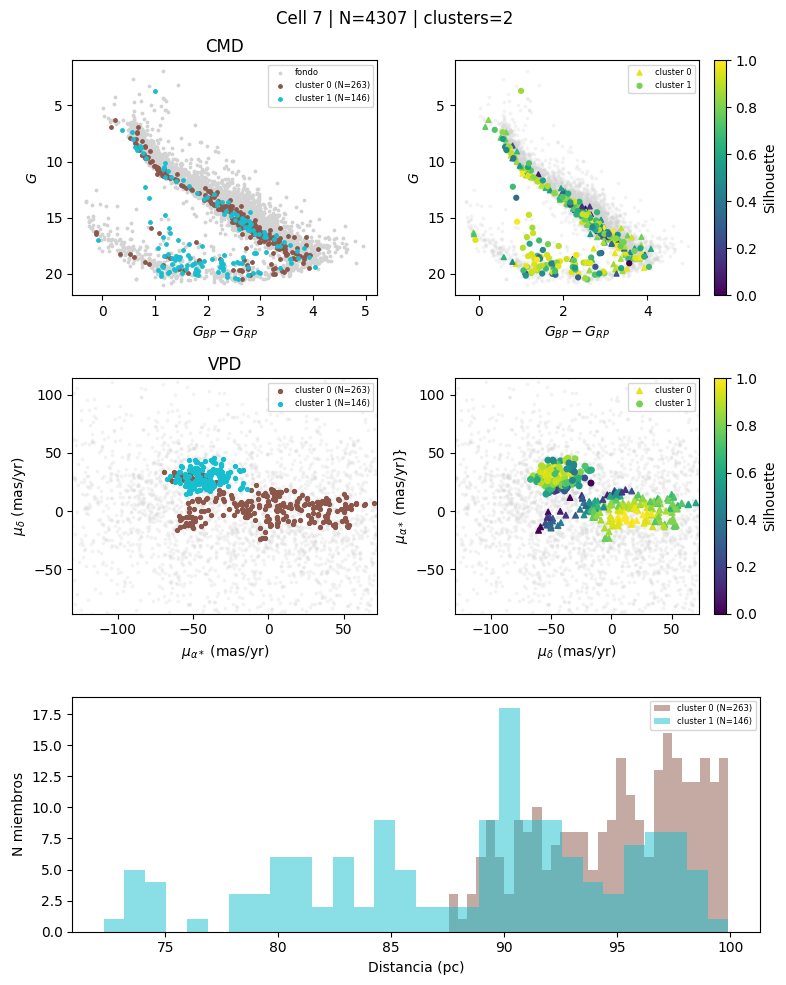

 11%|█         | 7/66 [00:07<01:17,  1.31s/it]


Cell 8
N estrellas: 1434
N clusters encontrados: 0
Solo ruido, no se grafica

Cell 9
N estrellas: 1391
N clusters encontrados: 2
[TAMAÑO] Cluster 0 eliminado | N=46 | Δd=9.96 pc
[TAMAÑO] Cluster 1 eliminado | N=77 | Δd=20.02 pc
Todos los clusters eliminados tras cortes

Cell 10
N estrellas: 3863
N clusters encontrados: 2


 15%|█▌        | 10/66 [00:08<00:36,  1.52it/s]

[TAMAÑO] Cluster 1 eliminado | N=61 | Δd=22.27 pc
[EXTENSIÓN] Cluster 0 eliminado | N=967 | Δd=34.86 pc
Todos los clusters eliminados tras cortes

Cell 11
N estrellas: 5981
N clusters encontrados: 2


 17%|█▋        | 11/66 [00:09<00:40,  1.35it/s]

[TAMAÑO] Cluster 0 eliminado | N=2161 | Δd=39.16 pc
[TAMAÑO] Cluster 1 eliminado | N=81 | Δd=16.65 pc
Todos los clusters eliminados tras cortes

Cell 12
N estrellas: 7019
N clusters encontrados: 2


 18%|█▊        | 12/66 [00:10<00:47,  1.15it/s]

[TAMAÑO] Cluster 0 eliminado | N=1261 | Δd=27.76 pc
[TAMAÑO] Cluster 1 eliminado | N=50 | Δd=13.48 pc
Todos los clusters eliminados tras cortes

Cell 13
N estrellas: 5925
N clusters encontrados: 2


 20%|█▉        | 13/66 [00:11<00:46,  1.14it/s]

[TAMAÑO] Cluster 0 eliminado | N=1777 | Δd=33.97 pc
[TAMAÑO] Cluster 1 eliminado | N=49 | Δd=7.07 pc
Todos los clusters eliminados tras cortes

Cell 14
N estrellas: 5760
N clusters encontrados: 4
[TAMAÑO] Cluster 0 eliminado | N=63 | Δd=11.86 pc
[TAMAÑO] Cluster 3 eliminado | N=46 | Δd=12.92 pc
[TENDENCIA] Cluster 1 eliminado | N=397 | Δd=28.38 pc | slope=6.44


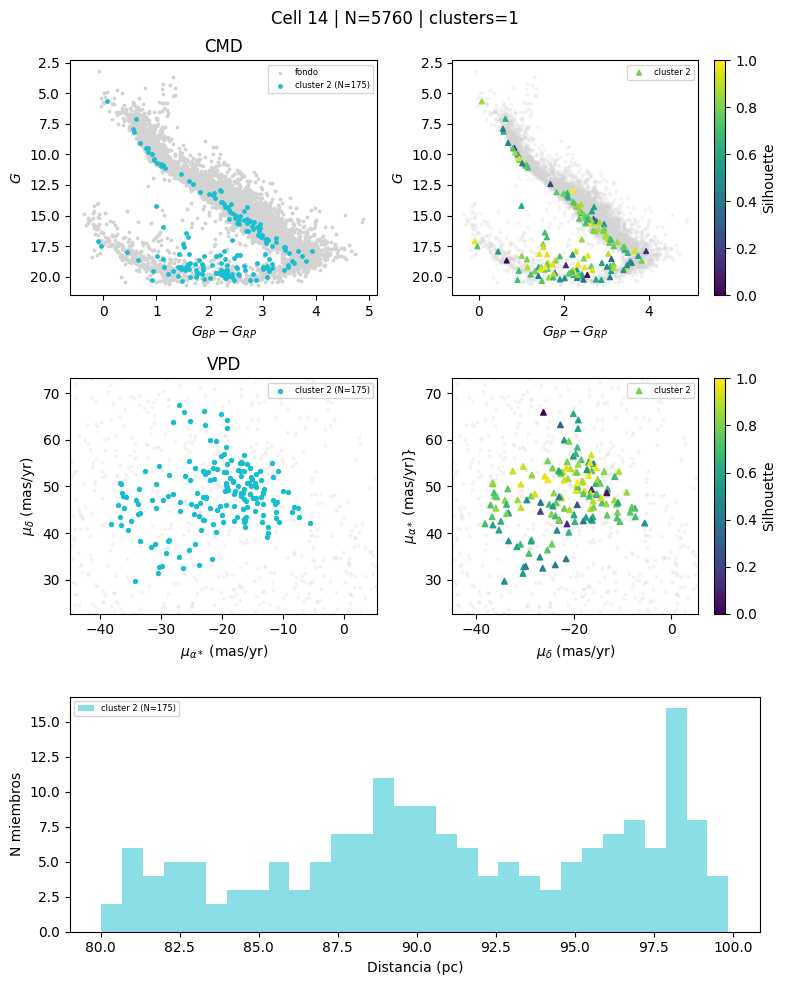

 21%|██        | 14/66 [00:13<00:59,  1.15s/it]


Cell 15
N estrellas: 4246
N clusters encontrados: 2


 26%|██▌       | 17/66 [00:14<00:28,  1.70it/s]

[TAMAÑO] Cluster 0 eliminado | N=73 | Δd=14.51 pc
[TENDENCIA] Cluster 1 eliminado | N=686 | Δd=20.46 pc | slope=8.04
Todos los clusters eliminados tras cortes

Cell 16
N estrellas: 1496
N clusters encontrados: 2
[TAMAÑO] Cluster 1 eliminado | N=46 | Δd=21.32 pc
[EXTENSIÓN] Cluster 0 eliminado | N=398 | Δd=40.70 pc
Todos los clusters eliminados tras cortes

Cell 17
N estrellas: 1470
N clusters encontrados: 2
[TAMAÑO] Cluster 1 eliminado | N=58 | Δd=23.91 pc
[EXTENSIÓN] Cluster 0 eliminado | N=264 | Δd=35.75 pc
Todos los clusters eliminados tras cortes

Cell 18
N estrellas: 4140
N clusters encontrados: 2


 27%|██▋       | 18/66 [00:14<00:27,  1.77it/s]

[TAMAÑO] Cluster 0 eliminado | N=45 | Δd=11.14 pc
[TENDENCIA] Cluster 1 eliminado | N=622 | Δd=21.21 pc | slope=6.78
Todos los clusters eliminados tras cortes

Cell 19
N estrellas: 7175
N clusters encontrados: 2
[TAMAÑO] Cluster 0 eliminado | N=67 | Δd=10.91 pc


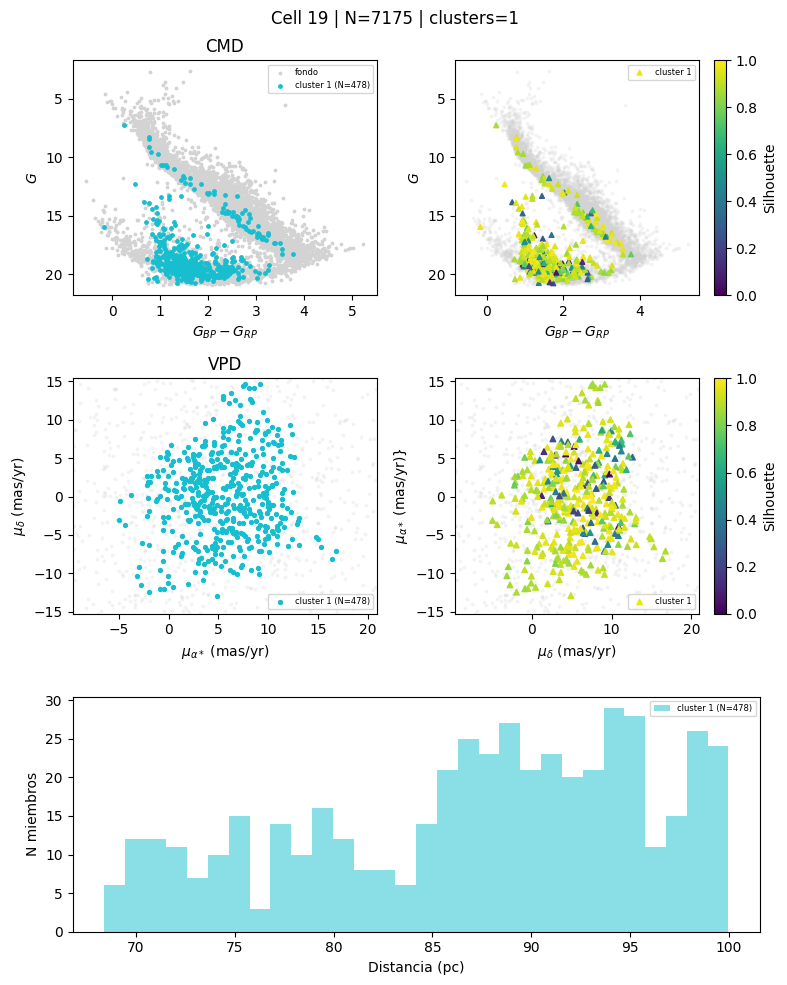

 29%|██▉       | 19/66 [00:17<00:48,  1.04s/it]


Cell 20
N estrellas: 7424
N clusters encontrados: 2
[TENDENCIA] Cluster 1 eliminado | N=560 | Δd=27.22 pc | slope=7.93


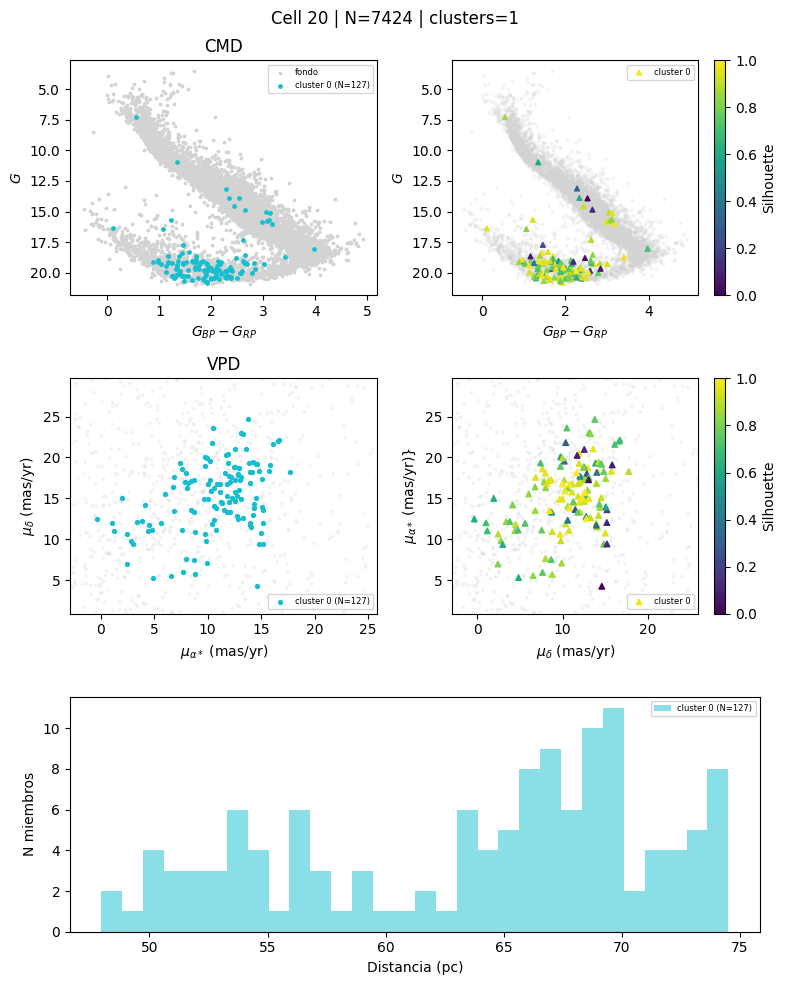

 30%|███       | 20/66 [00:20<01:15,  1.63s/it]


Cell 21
N estrellas: 6999
N clusters encontrados: 2


 32%|███▏      | 21/66 [00:22<01:11,  1.58s/it]

[TAMAÑO] Cluster 1 eliminado | N=49 | Δd=8.11 pc
[EXTENSIÓN] Cluster 0 eliminado | N=968 | Δd=35.46 pc
Todos los clusters eliminados tras cortes

Cell 22
N estrellas: 5788
N clusters encontrados: 2
[TAMAÑO] Cluster 1 eliminado | N=87 | Δd=9.11 pc


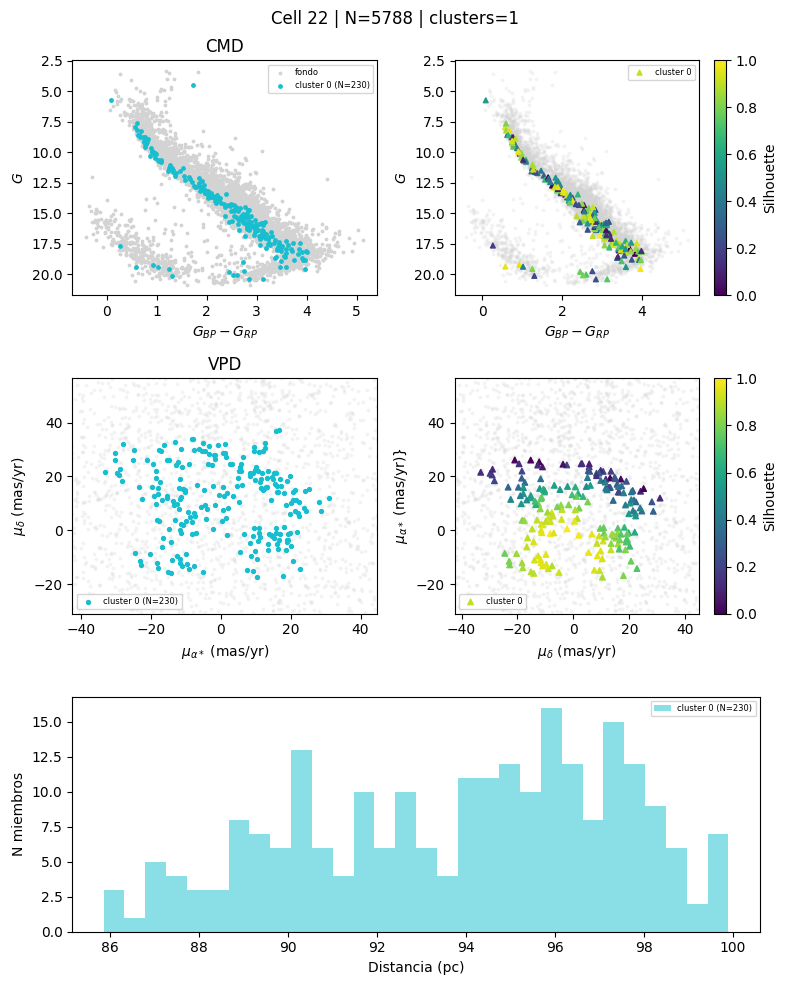

 33%|███▎      | 22/66 [00:23<01:14,  1.69s/it]


Cell 23
N estrellas: 3993
N clusters encontrados: 2


 35%|███▍      | 23/66 [00:24<00:56,  1.32s/it]

[TAMAÑO] Cluster 1 eliminado | N=68 | Δd=17.92 pc
[TENDENCIA] Cluster 0 eliminado | N=819 | Δd=33.04 pc | slope=12.69
Todos los clusters eliminados tras cortes

Cell 24
N estrellas: 1445
N clusters encontrados: 0
Solo ruido, no se grafica

Cell 25
N estrellas: 1517
N clusters encontrados: 2
[TAMAÑO] Cluster 0 eliminado | N=54 | Δd=11.62 pc


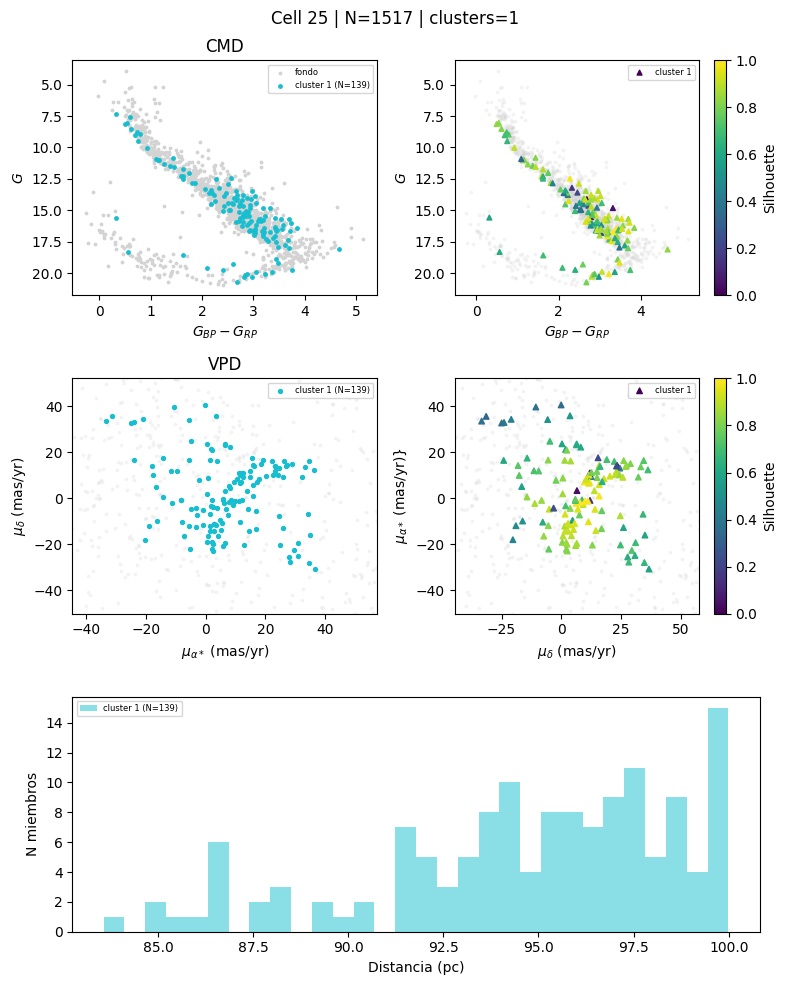

 38%|███▊      | 25/66 [00:25<00:38,  1.05it/s]


Cell 26
N estrellas: 4167
N clusters encontrados: 2


 39%|███▉      | 26/66 [00:25<00:33,  1.18it/s]

[TAMAÑO] Cluster 0 eliminado | N=1253 | Δd=42.67 pc
[TAMAÑO] Cluster 1 eliminado | N=68 | Δd=16.62 pc
Todos los clusters eliminados tras cortes

Cell 27
N estrellas: 6191
N clusters encontrados: 2


 41%|████      | 27/66 [00:27<00:35,  1.08it/s]

...

[TAMAÑO] Cluster 0 eliminado | N=1772 | Δd=39.58 pc
[TAMAÑO] Cluster 1 eliminado | N=46 | Δd=11.60 pc
Todos los clusters eliminados tras cortes

Cell 29
N estrellas: 6014
N clusters encontrados: 3


 44%|████▍     | 29/66 [00:29<00:36,  1.01it/s]

[TAMAÑO] Cluster 0 eliminado | N=70 | Δd=20.81 pc
[TAMAÑO] Cluster 1 eliminado | N=2157 | Δd=45.85 pc
[TAMAÑO] Cluster 2 eliminado | N=55 | Δd=9.64 pc
Todos los clusters eliminados tras cortes

Cell 30
N estrellas: 4880
N clusters encontrados: 2


 45%|████▌     | 30/66 [00:29<00:31,  1.13it/s]

[TAMAÑO] Cluster 0 eliminado | N=1550 | Δd=42.45 pc
[TAMAÑO] Cluster 1 eliminado | N=56 | Δd=12.86 pc
Todos los clusters eliminados tras cortes

Cell 31
N estrellas: 3761
N clusters encontrados: 2
[TAMAÑO] Cluster 0 eliminado | N=87 | Δd=22.39 pc


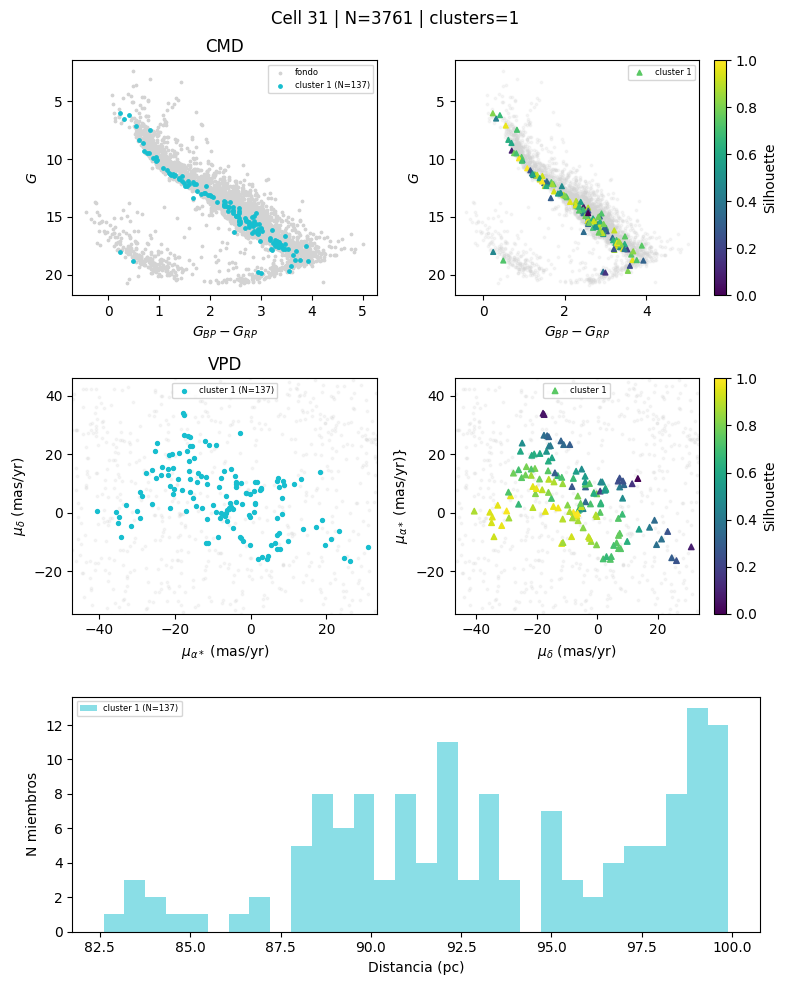

 47%|████▋     | 31/66 [00:30<00:33,  1.04it/s]


Cell 32
N estrellas: 1373
N clusters encontrados: 2
[TAMAÑO] Cluster 1 eliminado | N=85 | Δd=37.19 pc
[EXTENSIÓN] Cluster 0 eliminado | N=216 | Δd=34.29 pc
Todos los clusters eliminados tras cortes

Cell 33
N estrellas: 1514
N clusters encontrados: 0
Solo ruido, no se grafica

Cell 34
N estrellas: 5863
N clusters encontrados: 2


 52%|█████▏    | 34/66 [00:32<00:20,  1.59it/s]

[TAMAÑO] Cluster 0 eliminado | N=3354 | Δd=72.08 pc
[TAMAÑO] Cluster 1 eliminado | N=55 | Δd=20.26 pc
Todos los clusters eliminados tras cortes

Cell 35
N estrellas: 6379
N clusters encontrados: 2
[TAMAÑO] Cluster 1 eliminado | N=46 | Δd=10.82 pc


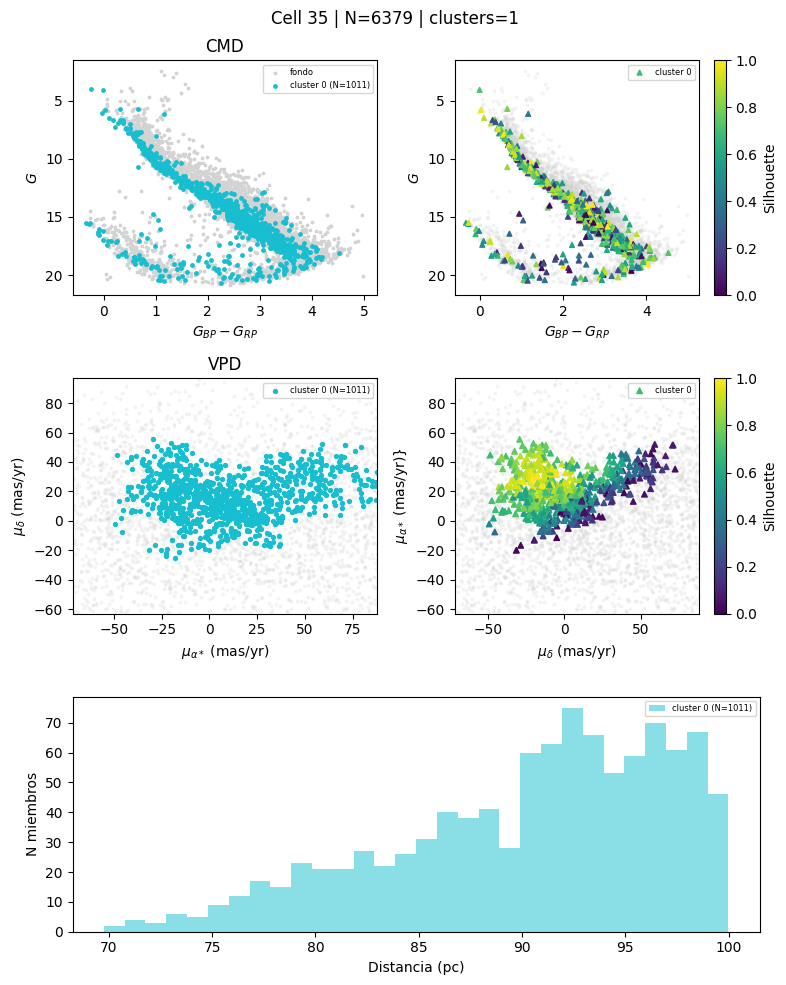

 53%|█████▎    | 35/66 [00:34<00:30,  1.00it/s]


Cell 36
N estrellas: 7020
N clusters encontrados: 2


 55%|█████▍    | 36/66 [00:35<00:33,  1.11s/it]

[TAMAÑO] Cluster 0 eliminado | N=3884 | Δd=58.99 pc
[TAMAÑO] Cluster 1 eliminado | N=45 | Δd=18.04 pc
Todos los clusters eliminados tras cortes

Cell 37
N estrellas: 5630
N clusters encontrados: 2


 56%|█████▌    | 37/66 [00:36<00:31,  1.08s/it]

[TAMAÑO] Cluster 1 eliminado | N=71 | Δd=17.53 pc
[TENDENCIA] Cluster 0 eliminado | N=915 | Δd=31.21 pc | slope=13.82
Todos los clusters eliminados tras cortes

Cell 38
N estrellas: 4170
N clusters encontrados: 2


 58%|█████▊    | 38/66 [00:37<00:25,  1.10it/s]

[TAMAÑO] Cluster 0 eliminado | N=1853 | Δd=52.67 pc
[TAMAÑO] Cluster 1 eliminado | N=52 | Δd=25.61 pc
Todos los clusters eliminados tras cortes

Cell 39
N estrellas: 3935
N clusters encontrados: 5
[TAMAÑO] Cluster 0 eliminado | N=49 | Δd=19.94 pc
[TAMAÑO] Cluster 1 eliminado | N=69 | Δd=13.58 pc
[TAMAÑO] Cluster 2 eliminado | N=45 | Δd=10.07 pc
[TENDENCIA] Cluster 4 eliminado | N=259 | Δd=21.36 pc | slope=4.23


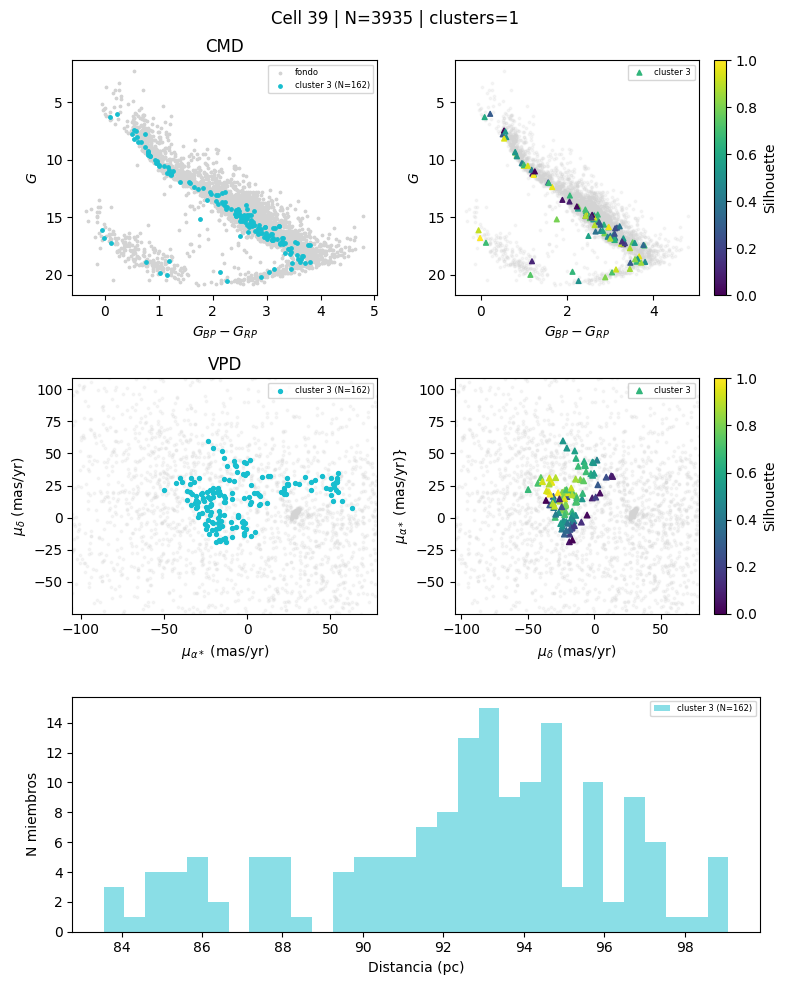

 62%|██████▏   | 41/66 [00:38<00:14,  1.73it/s]


Cell 40
N estrellas: 1387
N clusters encontrados: 0
Solo ruido, no se grafica

Cell 41
N estrellas: 1607
N clusters encontrados: 2
[TAMAÑO] Cluster 0 eliminado | N=53 | Δd=14.39 pc
[TAMAÑO] Cluster 1 eliminado | N=47 | Δd=23.96 pc
Todos los clusters eliminados tras cortes

Cell 42
N estrellas: 6578
N clusters encontrados: 3
[TAMAÑO] Cluster 0 eliminado | N=61 | Δd=17.42 pc
[TAMAÑO] Cluster 2 eliminado | N=2415 | Δd=61.56 pc


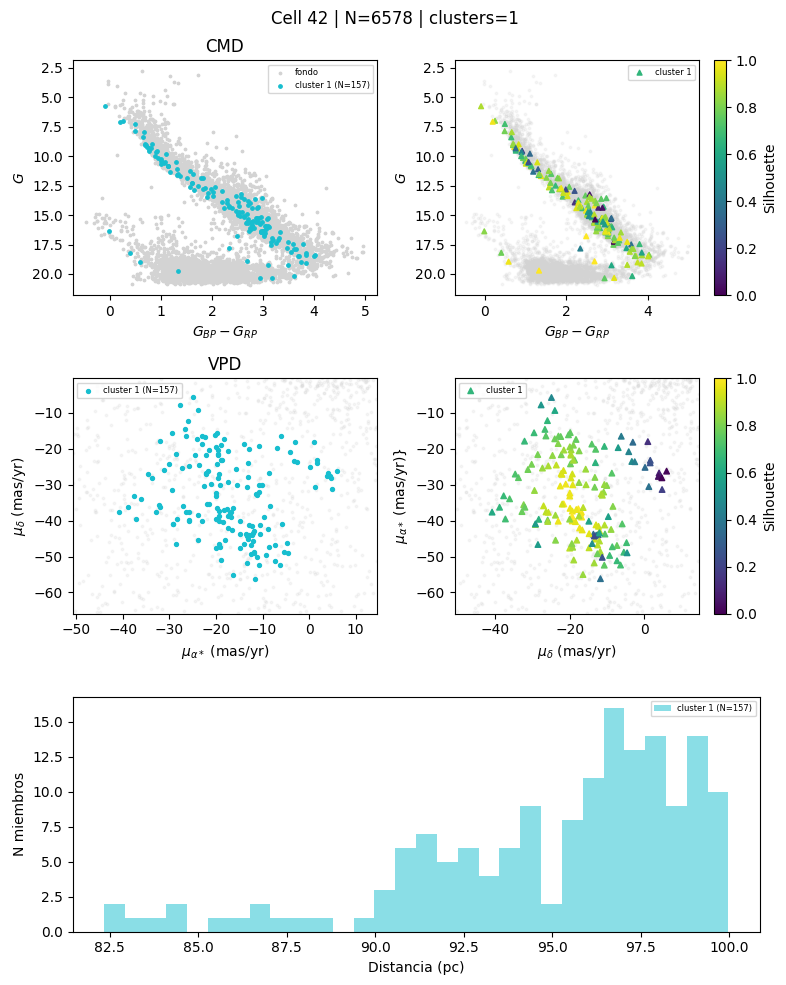

 64%|██████▎   | 42/66 [00:40<00:21,  1.11it/s]


Cell 43
N estrellas: 27671
N clusters encontrados: 5


 65%|██████▌   | 43/66 [00:56<01:49,  4.74s/it]

[TAMAÑO] Cluster 0 eliminado | N=87 | Δd=34.84 pc
[TAMAÑO] Cluster 1 eliminado | N=53 | Δd=26.82 pc
[TAMAÑO] Cluster 2 eliminado | N=21204 | Δd=77.95 pc
[TAMAÑO] Cluster 3 eliminado | N=72 | Δd=12.41 pc
[TENDENCIA] Cluster 4 eliminado | N=156 | Δd=28.80 pc | slope=3.15
Todos los clusters eliminados tras cortes

Cell 44
N estrellas: 12000
N clusters encontrados: 4
[TAMAÑO] Cluster 0 eliminado | N=55 | Δd=9.98 pc
[TENDENCIA] Cluster 2 eliminado | N=531 | Δd=25.68 pc | slope=3.44


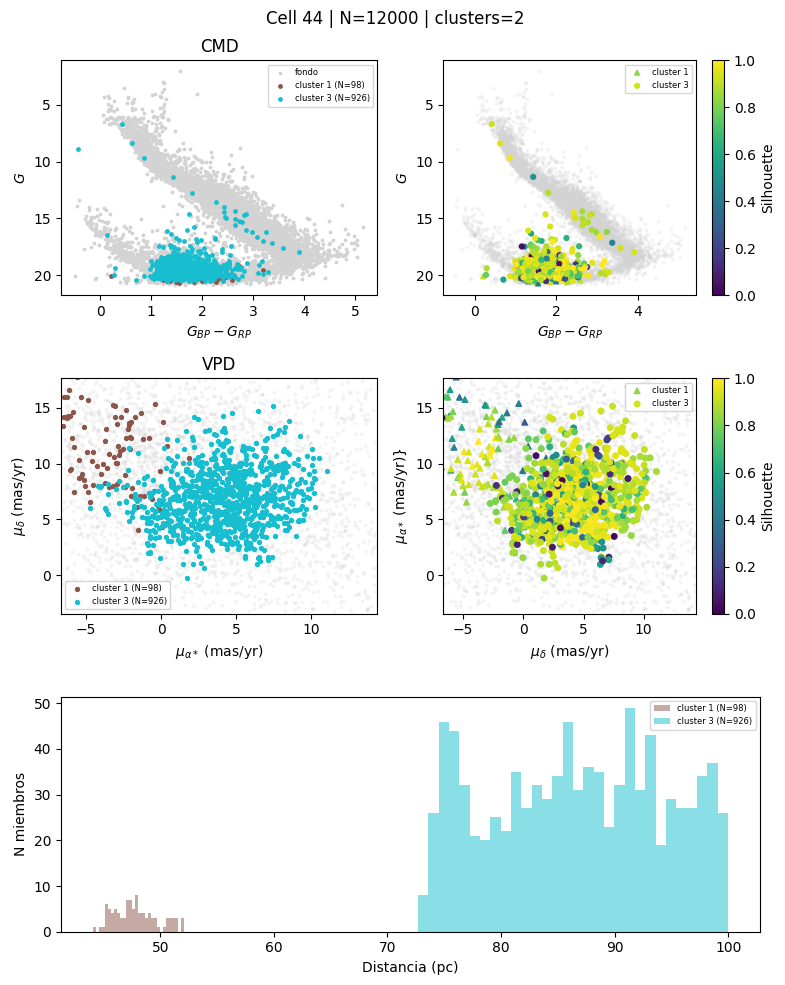

 67%|██████▋   | 44/66 [01:01<01:46,  4.86s/it]


Cell 45
N estrellas: 7295
N clusters encontrados: 2


 68%|██████▊   | 45/66 [01:03<01:23,  3.98s/it]

[TAMAÑO] Cluster 0 eliminado | N=1968 | Δd=38.31 pc
[TAMAÑO] Cluster 1 eliminado | N=54 | Δd=16.07 pc
Todos los clusters eliminados tras cortes

Cell 46
N estrellas: 6094
N clusters encontrados: 2


 70%|██████▉   | 46/66 [01:04<01:04,  3.20s/it]

[TAMAÑO] Cluster 0 eliminado | N=2288 | Δd=47.64 pc
[TAMAÑO] Cluster 1 eliminado | N=53 | Δd=14.89 pc
Todos los clusters eliminados tras cortes

Cell 47
N estrellas: 3946
N clusters encontrados: 3
[TAMAÑO] Cluster 0 eliminado | N=45 | Δd=14.88 pc
[TAMAÑO] Cluster 1 eliminado | N=88 | Δd=15.88 pc


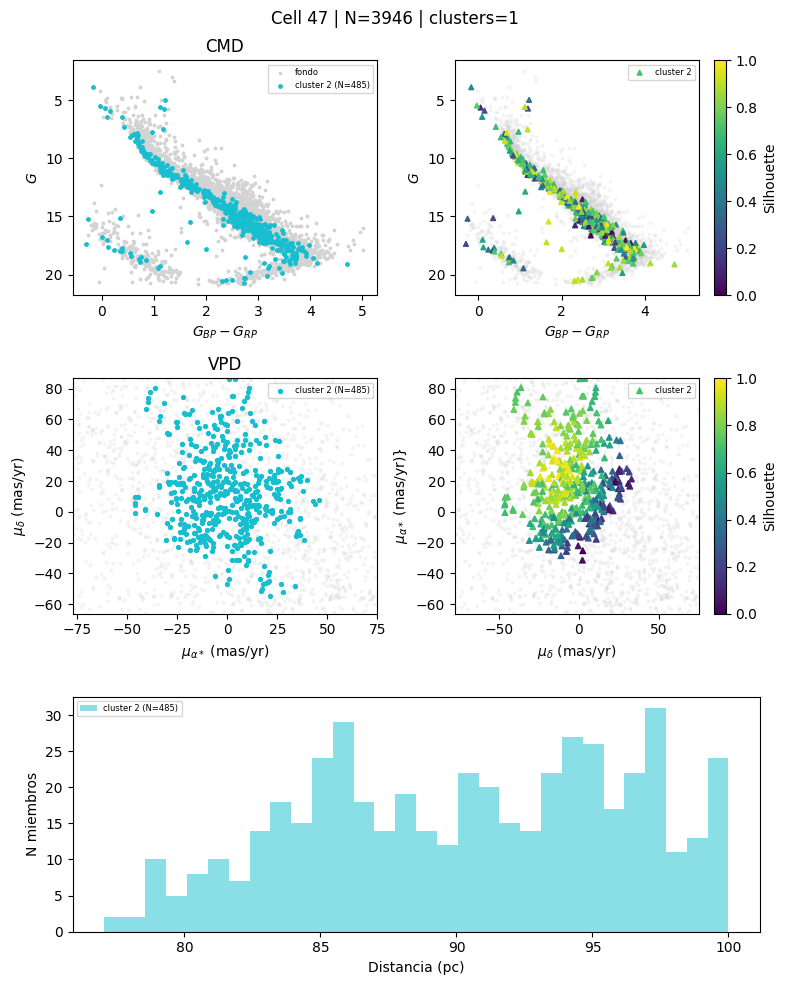

 71%|███████   | 47/66 [01:06<00:51,  2.69s/it]


Cell 48
N estrellas: 1491
N clusters encontrados: 2
[TAMAÑO] Cluster 0 eliminado | N=66 | Δd=26.87 pc


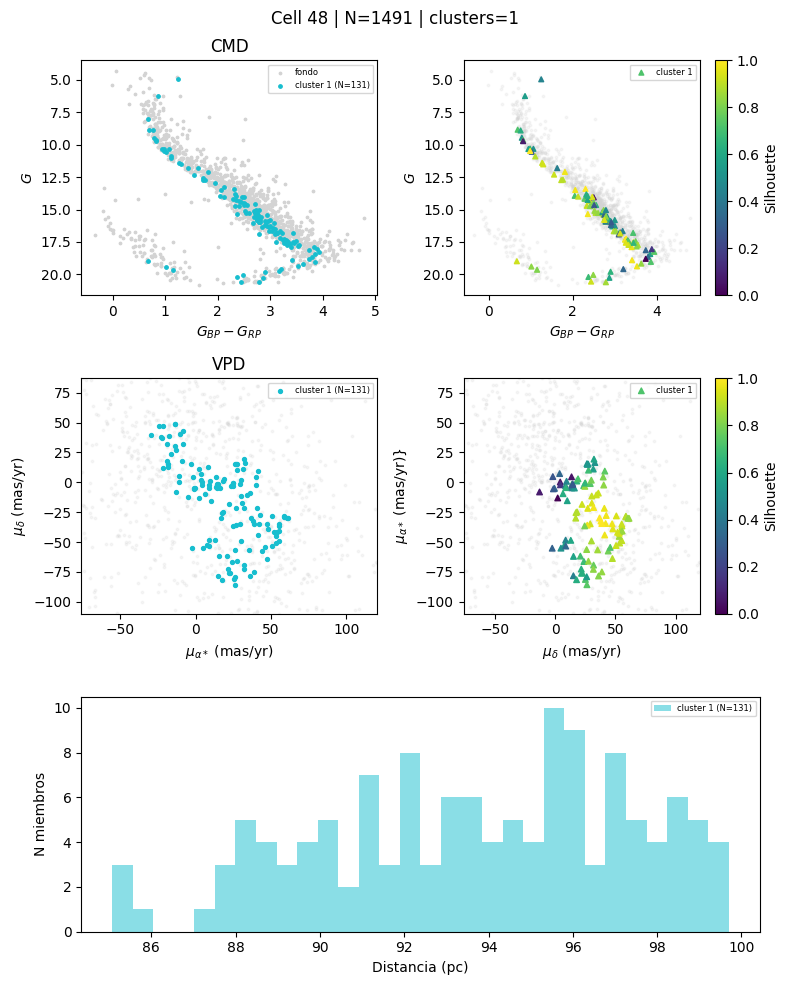

 73%|███████▎  | 48/66 [01:07<00:39,  2.18s/it]


Cell 49
N estrellas: 1543
N clusters encontrados: 0
Solo ruido, no se grafica

Cell 50
N estrellas: 4338
N clusters encontrados: 2


 76%|███████▌  | 50/66 [01:07<00:21,  1.34s/it]

[TAMAÑO] Cluster 1 eliminado | N=61 | Δd=16.10 pc
[EXTENSIÓN] Cluster 0 eliminado | N=1022 | Δd=42.58 pc
Todos los clusters eliminados tras cortes

Cell 51
N estrellas: 12516
N clusters encontrados: 4
[TAMAÑO] Cluster 0 eliminado | N=48 | Δd=24.97 pc
[TAMAÑO] Cluster 3 eliminado | N=6186 | Δd=72.78 pc


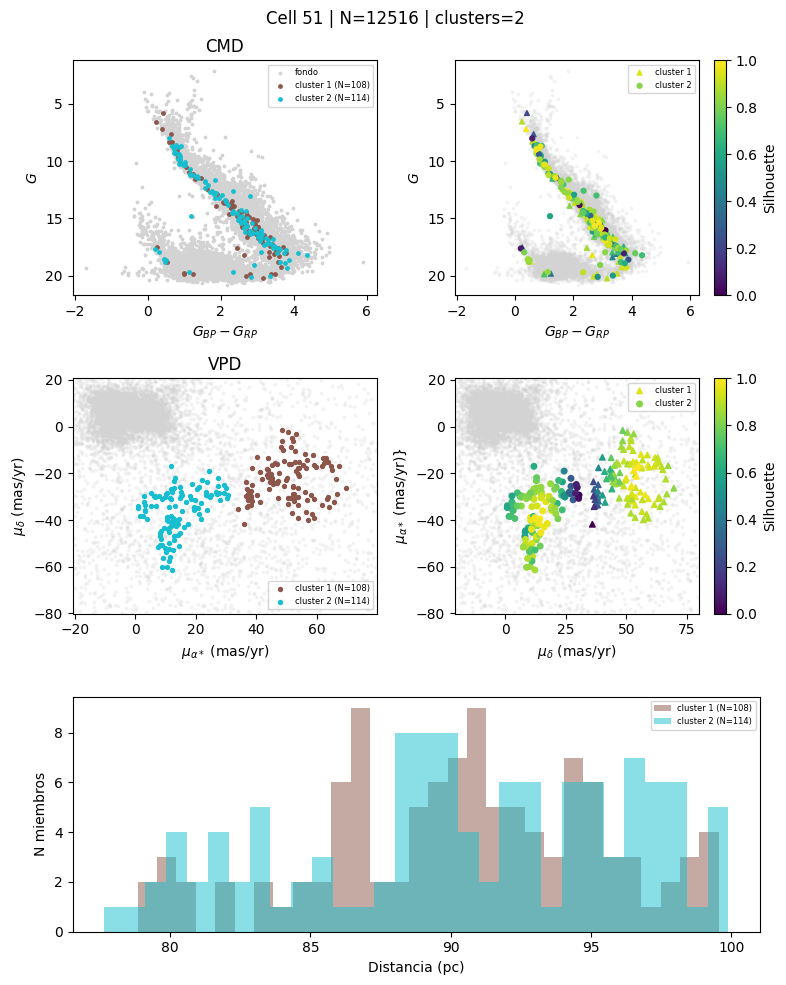

 77%|███████▋  | 51/66 [01:13<00:37,  2.52s/it]


Cell 52
N estrellas: 12219
N clusters encontrados: 5
[TAMAÑO] Cluster 0 eliminado | N=47 | Δd=17.99 pc
[TAMAÑO] Cluster 1 eliminado | N=56 | Δd=15.58 pc
[TAMAÑO] Cluster 2 eliminado | N=5127 | Δd=71.27 pc
[TAMAÑO] Cluster 3 eliminado | N=76 | Δd=18.55 pc


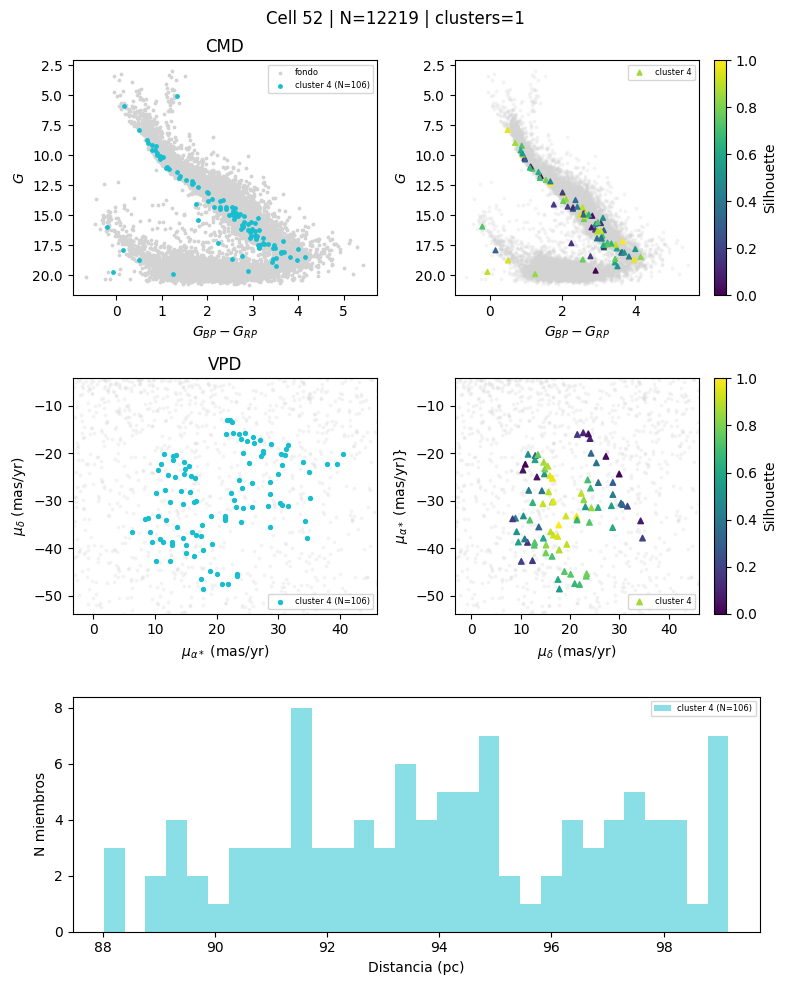

 79%|███████▉  | 52/66 [01:19<00:46,  3.33s/it]


Cell 53
N estrellas: 11638
N clusters encontrados: 4


 80%|████████  | 53/66 [01:22<00:42,  3.29s/it]

[TAMAÑO] Cluster 0 eliminado | N=60 | Δd=19.79 pc
[TAMAÑO] Cluster 1 eliminado | N=63 | Δd=22.13 pc
[TAMAÑO] Cluster 2 eliminado | N=4148 | Δd=74.79 pc
[TAMAÑO] Cluster 3 eliminado | N=51 | Δd=14.84 pc
Todos los clusters eliminados tras cortes

Cell 54
N estrellas: 9276
N clusters encontrados: 4


 82%|████████▏ | 54/66 [01:24<00:35,  2.98s/it]

...

[TAMAÑO] Cluster 0 eliminado | N=49 | Δd=15.35 pc
[TAMAÑO] Cluster 1 eliminado | N=65 | Δd=16.86 pc
[TAMAÑO] Cluster 2 eliminado | N=1411 | Δd=36.40 pc
Todos los clusters eliminados tras cortes

Cell 60
N estrellas: 6982
N clusters encontrados: 3


 91%|█████████ | 60/66 [01:28<00:06,  1.08s/it]

[TAMAÑO] Cluster 0 eliminado | N=51 | Δd=19.02 pc
[TAMAÑO] Cluster 1 eliminado | N=1511 | Δd=39.77 pc
[TAMAÑO] Cluster 2 eliminado | N=54 | Δd=13.46 pc
Todos los clusters eliminados tras cortes

Cell 61
N estrellas: 7011
N clusters encontrados: 2


 92%|█████████▏| 61/66 [01:29<00:05,  1.14s/it]

[TAMAÑO] Cluster 0 eliminado | N=2969 | Δd=53.63 pc
[TAMAÑO] Cluster 1 eliminado | N=68 | Δd=24.29 pc
Todos los clusters eliminados tras cortes

Cell 62
N estrellas: 6341
N clusters encontrados: 3
[TAMAÑO] Cluster 2 eliminado | N=59 | Δd=11.41 pc
[TENDENCIA] Cluster 1 eliminado | N=451 | Δd=20.34 pc | slope=7.00


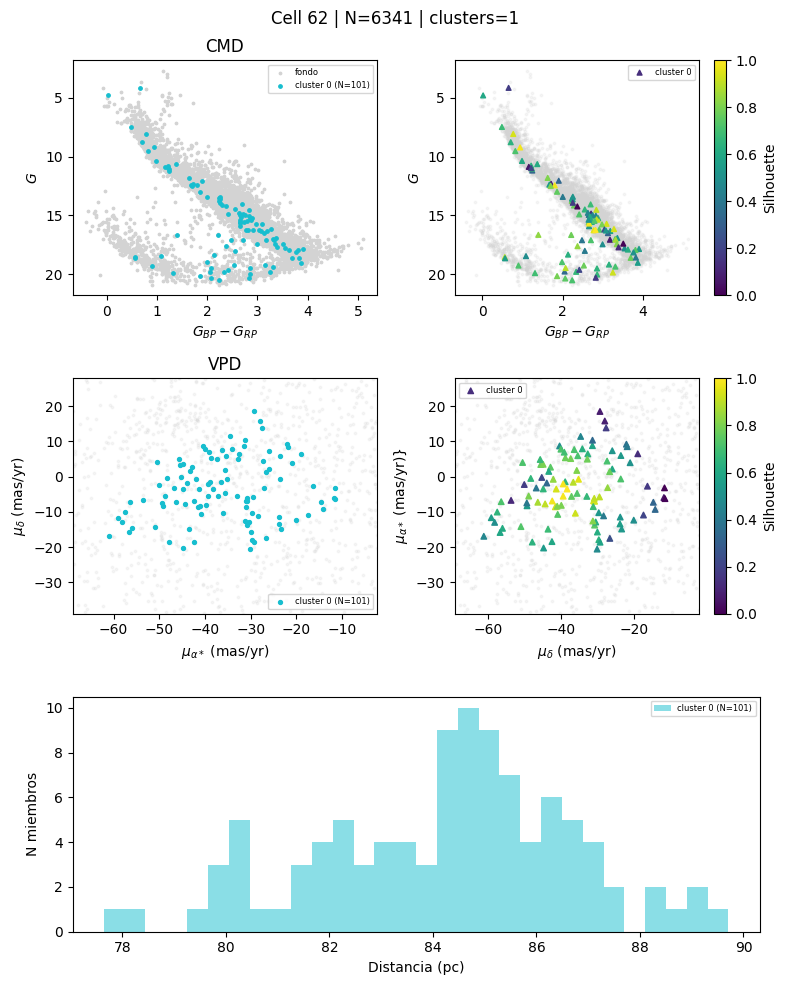

 94%|█████████▍| 62/66 [01:31<00:05,  1.36s/it]


Cell 63
N estrellas: 4381
N clusters encontrados: 2


 95%|█████████▌| 63/66 [01:31<00:03,  1.10s/it]

[TAMAÑO] Cluster 0 eliminado | N=1274 | Δd=37.50 pc
[TAMAÑO] Cluster 1 eliminado | N=46 | Δd=14.47 pc
Todos los clusters eliminados tras cortes

Cell 64
N estrellas: 1520
N clusters encontrados: 2
[TAMAÑO] Cluster 1 eliminado | N=58 | Δd=22.84 pc
[EXTENSIÓN] Cluster 0 eliminado | N=660 | Δd=46.91 pc
Todos los clusters eliminados tras cortes

Cell 65
N estrellas: 2367
N clusters encontrados: 3
[TAMAÑO] Cluster 0 eliminado | N=46 | Δd=6.61 pc
[TAMAÑO] Cluster 2 eliminado | N=49 | Δd=8.86 pc


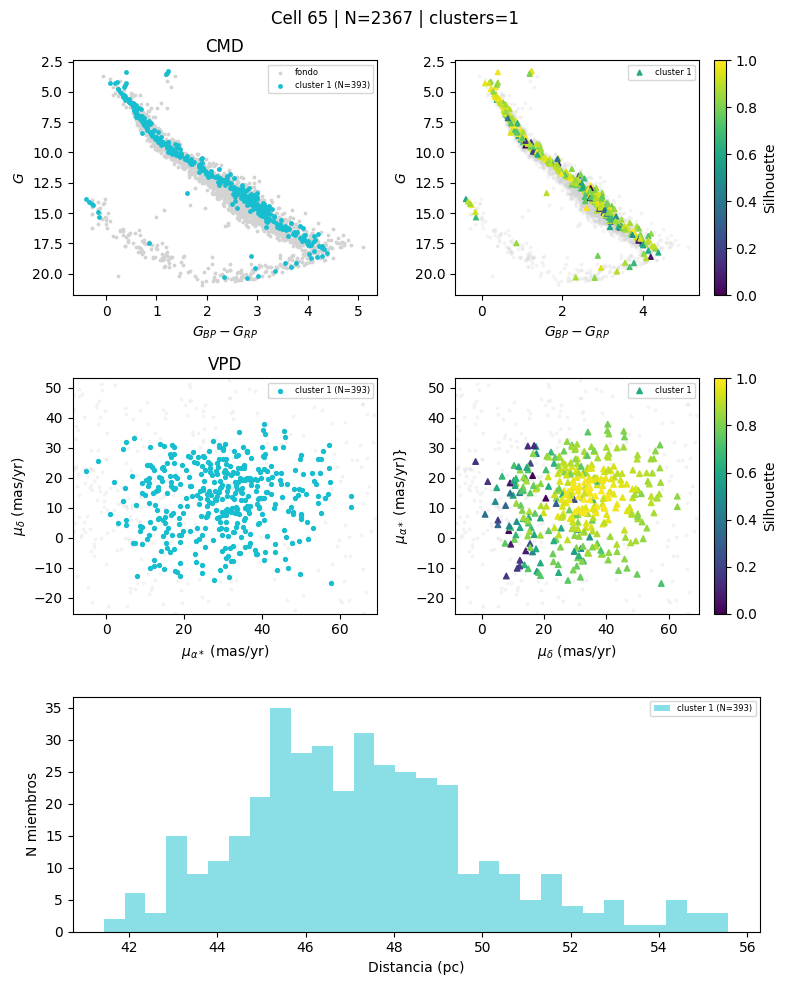

 98%|█████████▊| 65/66 [01:32<00:00,  1.20it/s]


Cell 66
N estrellas: 3874
N clusters encontrados: 3
[TAMAÑO] Cluster 2 eliminado | N=70 | Δd=8.69 pc


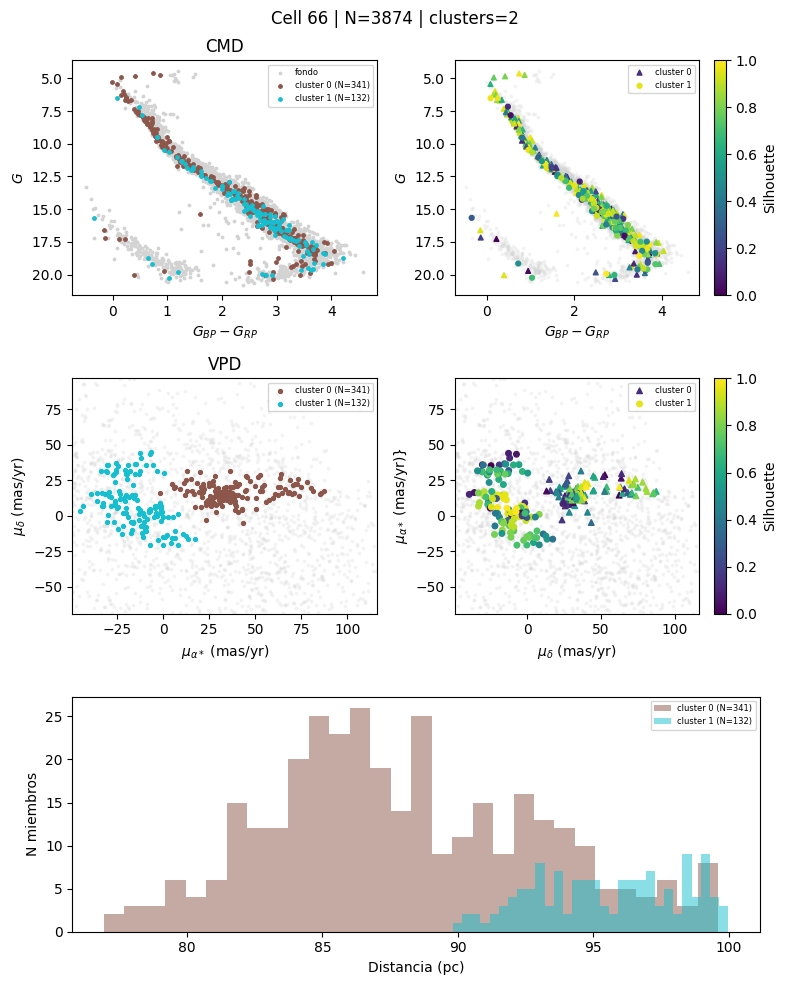

100%|██████████| 66/66 [01:34<00:00,  1.43s/it]


In [9]:
clustering_on = ['pmra','pmdec','dist_pc']
unique_ids = set()
results = []

for cell_id in tqdm(sorted(df["cell_id"].unique())):

    df_cell = df[df["cell_id"] == cell_id].copy()

    n_stars = len(df_cell)
    unique_ids.update(df_cell.index)

    print("\n==============================")
    print(f"Cell {cell_id}")
    print(f"N estrellas: {n_stars}")

    # preparar datos
    features = df_cell[['pmra','pmdec','dist_pc']]
    data_scaled = RobustScaler().fit_transform(features)

    # HDBSCAN
    hd = HDBSCAN(min_cluster_size=45,min_samples=5,metric='euclidean').fit(data_scaled)
    labels = hd.labels_
    df_cell["label_hb"] = labels
    unique_labels = set(labels)
    n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
    print(f"N clusters encontrados: {n_clusters}")
    
    if n_clusters == 0:
        print("Solo ruido, no se grafica")
        results.append(df_cell)
        continue

    # silhouette
    if n_clusters > 1:
        sil = silhouette_samples(data_scaled, labels)
        df_cell["silhouette"] = sil
    else:
        df_cell["silhouette"] = np.nan

    # centrar VPD
    df_cell["pmra_rel"] = df_cell["pmra"] - df_cell["pmra"].median()
    df_cell["pmdec_rel"] = df_cell["pmdec"] - df_cell["pmdec"].median()

    # tamaños de clusters
    cluster_sizes = {lab: np.sum(df_cell["label_hb"] == lab) for lab in unique_labels if lab != -1}

    # CORTE POR TAMAÑO
    for lab in list(cluster_sizes.keys()):
        size = cluster_sizes[lab]
        if size > 1050:
            cond = df_cell["label_hb"] == lab
            extension = df_cell.loc[cond, "dist_pc"].max() - df_cell.loc[cond, "dist_pc"].min()
            print(f"[TAMAÑO] Cluster {lab} eliminado | N={size} | Δd={extension:.2f} pc")
            df_cell.loc[cond, "label_hb"] = -1
            del cluster_sizes[lab]

        elif size < 95:    
            cond = df_cell["label_hb"] == lab
            extension = df_cell.loc[cond, "dist_pc"].max() - df_cell.loc[cond, "dist_pc"].min()
            print(f"[TAMAÑO] Cluster {lab} eliminado | N={size} | Δd={extension:.2f} pc")
            df_cell.loc[cond, "label_hb"] = -1
            del cluster_sizes[lab]

    # CORTE EN EXTENSIÓN 
    for lab in list(cluster_sizes.keys()):
        cond = df_cell["label_hb"] == lab
        dist_cluster = df_cell.loc[cond, "dist_pc"]
        extension = dist_cluster.max() - dist_cluster.min()
        if extension > 34:
            print(f"[EXTENSIÓN] Cluster {lab} eliminado | N={cluster_sizes[lab]} | Δd={extension:.2f} pc")
            # Re-etiquetar como ruido
            df_cell.loc[cond, "label_hb"] = -1
            # eliminar del diccionario
            del cluster_sizes[lab]
            
    ################ CORTE POR MONOTONÍA
    for lab in list(cluster_sizes.keys()):
        cond = df_cell["label_hb"] == lab
        dist_cluster = df_cell.loc[cond, "dist_pc"]
        counts, _ = np.histogram(dist_cluster, bins=12)

        # pendiente global
        x = np.arange(len(counts))
        coef = np.polyfit(x, counts, 1)[0]

        # fracción de incrementos positivos
        diffs = np.diff(counts)
        frac_positive = np.sum(diffs >= 0) / len(diffs)
        slope_threshold = 2.5   
        frac_threshold = 0.65   
        is_bad_distribution = (coef > slope_threshold) and (frac_positive > frac_threshold)

        if is_bad_distribution:
            extension = dist_cluster.max() - dist_cluster.min()
            print(f"[TENDENCIA] Cluster {lab} eliminado | N={cluster_sizes[lab]} | Δd={extension:.2f} pc | slope={coef:.2f}")
            df_cell.loc[cond, "label_hb"] = -1
            del cluster_sizes[lab]
    
    # Recalcular clusters
    n_clusters = len(cluster_sizes)
    if n_clusters == 0:
        print("Todos los clusters eliminados tras cortes")
        results.append(df_cell)
        continue

    # RECONSTRUIR CLUSTERS FINALES
    final_labels = np.unique(df_cell["label_hb"])
    final_labels = final_labels[final_labels != -1]
    cluster_sizes = {lab: np.sum(df_cell["label_hb"] == lab)for lab in final_labels}

    cluster_cmaps = ["viridis","plasma","cividis","coolwarm","magma","Blues","Reds","Greens"]
    markers = ['^', 'o', 's', 'D', 'v', 'P', '*', 'X']

    # CENTRO Y ESCALA VPD 
    mask_clusters = df_cell["label_hb"].isin(cluster_sizes.keys())
    if np.sum(mask_clusters) > 0:
        pmra_center = df_cell.loc[mask_clusters, "pmra_rel"].median()
        pmdec_center = df_cell.loc[mask_clusters, "pmdec_rel"].median()
        r = np.sqrt((df_cell.loc[mask_clusters, "pmra_rel"] - pmra_center)**2 +(df_cell.loc[mask_clusters, "pmdec_rel"] - pmdec_center)**2)
        r_max = np.percentile(r, 90) * 1.5
    else:
        pmra_center, pmdec_center, r_max = 0, 0, 5

    # colores 
    unique_labels = np.unique(df_cell["label_hb"])
    cmap = plt.cm.get_cmap('tab10', len(unique_labels))
    color_map = {lab: ('lightgray' if lab == -1 else cmap(i))for i, lab in enumerate(unique_labels)}

    # FIGURA
    fig = plt.figure(figsize=(8,10))
    gs = fig.add_gridspec(3,2)
    ax_cmd = fig.add_subplot(gs[0,0])
    ax_cmd_sil = fig.add_subplot(gs[0,1])
    ax_vpd = fig.add_subplot(gs[1,0])
    ax_vpd_sil = fig.add_subplot(gs[1,1])
    ax_hist = fig.add_subplot(gs[2,:])

    # CMD fondo
    ax_cmd.scatter(df_cell["bp_rp"], df_cell["phot_g_mean_mag"],c='lightgray', s=3, label="fondo")
    for lab in cluster_sizes:
        cond = df_cell["label_hb"] == lab
        ax_cmd.scatter(df_cell["bp_rp"][cond], df_cell["phot_g_mean_mag"][cond],s=6,
            color=color_map[lab], label=f"cluster {lab} (N={cluster_sizes[lab]})")

    ax_cmd.invert_yaxis()
    ax_cmd.set_title("CMD")
    ax_cmd.legend(fontsize=6)
    ax_cmd.set_xlabel(r"$G_{BP} - G_{RP}$")
    ax_cmd.set_ylabel(r"$G$")

    # CMD silueta
    sil_threshold = 0.1
    mask_bad = (df_cell["silhouette"] < sil_threshold) | (df_cell["label_hb"] == -1)
    ax_cmd_sil.scatter(df_cell["bp_rp"][mask_bad],df_cell["phot_g_mean_mag"][mask_bad],c='lightgray',s=3,alpha=0.2)
    ax_cmd_sil.invert_yaxis()
    ax_cmd_sil.set_xlabel(r"$G_{BP} - G_{RP}$")
    ax_cmd_sil.set_ylabel(r"$G$")

    # clusters individualmente
    for i, lab in enumerate(cluster_sizes):
        cond = (df_cell["label_hb"] == lab) & (df_cell["silhouette"] >= sil_threshold)
        sil_vals = df_cell.loc[cond, "silhouette"]
        if len(sil_vals) == 0:
            continue
        # normalización local
        s_min, s_max = sil_vals.min(), sil_vals.max()
        if s_max > s_min:
            sil_norm = (sil_vals - s_min) / (s_max - s_min)
        else:
            sil_norm = np.zeros_like(sil_vals)

        marker = markers[i % len(markers)]
        sc1 = ax_cmd_sil.scatter(df_cell["bp_rp"][cond],df_cell["phot_g_mean_mag"][cond],c=sil_norm, cmap = 'viridis', 
                           marker=marker,s=12,label=f"cluster {lab}")
        
    cbar = plt.colorbar(sc1, ax=ax_cmd_sil)
    cbar.set_label("Silhouette")
    ax_cmd_sil.legend(fontsize = 6)

    # VPD fondo
    ax_vpd.scatter(df_cell["pmra_rel"],df_cell["pmdec_rel"],c='lightgray',s=3,alpha=0.2)

    for lab in cluster_sizes:
        cond = df_cell["label_hb"] == lab
        ax_vpd.scatter(df_cell["pmra_rel"][cond],df_cell["pmdec_rel"][cond],
            s=8,color=color_map[lab],label=f"cluster {lab} (N={cluster_sizes[lab]})")
    ax_vpd.set_xlabel(r"$\mu_{\alpha*}$ (mas/yr)")
    ax_vpd.set_ylabel(r"$\mu_{\delta}$ (mas/yr)")

    # zoom
    ax_vpd.set_xlim(pmra_center - r_max, pmra_center + r_max)
    ax_vpd.set_ylim(pmdec_center - r_max, pmdec_center + r_max)
    ax_vpd.set_title("VPD")
    ax_vpd.legend(fontsize=6)

    # VPD SILUETA 
    sil_threshold = 0.1
    ax_vpd_sil.scatter(df_cell["pmra_rel"][mask_bad],df_cell["pmdec_rel"][mask_bad],c='lightgray',s=3,alpha=0.2)

    for i, lab in enumerate(cluster_sizes):
        cond = (df_cell["label_hb"] == lab) & (df_cell["silhouette"] >= sil_threshold)
        sil_vals = df_cell.loc[cond, "silhouette"]
        if len(sil_vals) == 0:
            continue
        s_min, s_max = sil_vals.min(), sil_vals.max()
        if s_max > s_min:
            sil_norm = (sil_vals - s_min) / (s_max - s_min)
        else:
            sil_norm = np.zeros_like(sil_vals)
        marker = markers[i % len(markers)]

        ax_vpd_sil.scatter(df_cell["pmra_rel"][cond],df_cell["pmdec_rel"][cond],c=sil_norm,
            cmap='viridis',marker=marker,s=16,label=f"cluster {lab}")
    cbar2 = plt.colorbar(sc1, ax=ax_vpd_sil)
    cbar2.set_label("Silhouette")
    ax_vpd_sil.legend(fontsize = 6)
    ax_vpd_sil.set_ylabel(r"$\mu_{\alpha*}$ (mas/yr)}")
    ax_vpd_sil.set_xlabel(r"$\mu_{\delta}$ (mas/yr)")

    # mismo zoom
    ax_vpd_sil.set_xlim(pmra_center - r_max, pmra_center + r_max)
    ax_vpd_sil.set_ylim(pmdec_center - r_max, pmdec_center + r_max)

    # HISTOGRAMA 
    for lab in cluster_sizes:
        cond = df_cell["label_hb"] == lab

        ax_hist.hist( df_cell["dist_pc"][cond],bins=30, alpha=0.5,color=color_map[lab],
                     label=f"cluster {lab} (N={cluster_sizes[lab]})")

    #ax_hist.set_yscale("log")
    ax_hist.set_xlabel("Distancia (pc)")
    ax_hist.set_ylabel("N miembros")
    ax_hist.legend(fontsize=6)

    plt.suptitle(f"Cell {cell_id} | N={n_stars} | clusters={n_clusters}")
    plt.tight_layout()
    plt.show()
    results.append(df_cell)

df_final = pd.concat(results)